# BTC Signal Classifier — Baseline MVP

**Strategy 1 | Binary Labels | No Regime Filter (Baseline)**

---

### Changelog vs. previous version

| # | Change | Section |
|---|---|---|
| ✅ 1 | `y` as Series instead of DataFrame | Section 3 |
| ✅ 2 | Target column renamed: `df['y']` instead of `df['label']` | Section 3 |
| ✅ 3 | Chronological holdout split 80/20 before CV | Section 4 |
| ✅ 4 | `scale_pos_weight` computed from `y_train` | Section 5 |
| ✅ 5 | sklearn `Pipeline` with `LGBMClassifier` + diagram | Section 5 |
| ✅ 6 | Walk-Forward CV runs on `X_train` only (not full dataset) | Section 6 |
| ✅ 7 | `gap=24` in `TimeSeriesSplit` | Section 6 |
| ✅ 8 | Training time visible per fold + total | Section 6 |
| ✅ 9 | Metrics table per fold (Precision / Recall / F1) | Section 6 |
| ✅ 10 | Learning curves — per fold | Section 7 |
| ✅ 11 | Learning curves — summary (mean ± std across folds) | Section 7 |
| ✅ 12 | Final classification report on holdout set | Section 8 |

## 1 — Imports

In [34]:
#!pip install matplotlib --quiet

In [35]:
import pandas as pd
import pandas_ta as ta
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)
from sklearn import set_config

from lightgbm import LGBMClassifier
import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')

set_config(display='diagram')

## 2 — Load Data & Feature Engineering

In [36]:
df = pd.read_csv('/Users/tobiassteinbach/code/rajeevankrajendran-creator/systematic_trading/systematic_trading_backend/notebooks/btc_1hour_cleaned.csv')

df['Open time']  = pd.to_datetime(df['Open time'])
df['Close time'] = pd.to_datetime(df['Close time'])
df = df.set_index('Open time')

print(f"Dataset shape: {df.shape}")
df.head(2)

Dataset shape: (71588, 11)


,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
Open time,,,,,,,,,,,
2018-01-01 00:00:00,13715.65,13715.65,13400.01,13529.01,443.356199,2018-01-01 00:59:59.999,5.993910e+06,5228,228.521921,3.090541e+06,0
2018-01-01 01:00:00,13528.99,13595.89,13155.38,13203.06,383.697006,2018-01-01 01:59:59.999,5.154522e+06,4534,180.840403,2.430449e+06,0


In [37]:
# ROC — Rate of Change
def compute_roc(df):
    df['roc_10'] = df['Close'].pct_change(periods=10)
    df['roc_21'] = df['Close'].pct_change(periods=21)
    return df

# MACD Histogram
def compute_macd(df):
    macd = ta.macd(df['Close'], fast=12, slow=26, signal=9)
    df['macd_histogram'] = macd['MACDh_12_26_9']
    return df

# ADX — used as feature AND for regime detection (execution layer)
def compute_adx(df):
    df['adx'] = ta.adx(df['High'], df['Low'], df['Close'], length=14)['ADX_14']
    return df

# RSI 14
def compute_rsi_14(df):
    df['rsi_14'] = ta.rsi(df['Close'], length=14)
    return df

# RSI divergence
def compute_rsi_div(df):

    df['price_high'] = df['Close'].rolling(14).max()
    df['price_low']  = df['Close'].rolling(14).min()
    df['rsi_high']   = df['rsi_14'].rolling(14).max()
    df['rsi_low']    = df['rsi_14'].rolling(14).min()

    bearish_div = (df['Close'] == df['price_high']) & (df['rsi_14'] < df['rsi_high'])
    bullish_div = (df['Close'] == df['price_low'])  & (df['rsi_14'] > df['rsi_low'])

    df['rsi_divergence'] = 0
    df.loc[bullish_div, 'rsi_divergence'] = 1
    df.loc[bearish_div, 'rsi_divergence'] = -1

    df.drop(columns=['price_high', 'price_low', 'rsi_high', 'rsi_low'], inplace=True)

    return df

# OBV Change (10 bars)
def compute_obv(df):
    direction = df['Close'].diff(1).apply(lambda x: 1 if x > 0 else (-1 if x < 0 else 0))
    obv = (df['Volume'] * direction).cumsum()
    df['obv_change'] = obv.diff(10)
    return df

# Volume ROC (10 bars)
def compute_vol_roc(df):
    df['volume_roc'] = df['Volume'].pct_change(periods=10)
    return df

# Boilinger bandwidth
def compute_boilinger(df):

    # Upper and Lower Band

    window = 20
    num_std = 2

    # 3. Calculate the Simple Moving Average (SMA_20)
    df['sma_20'] = df['Close'].rolling(window=window).mean()

    # 4. Calculate the Standard Deviation (sigma)
    df['sigma'] = df['Close'].rolling(window=window).std()

    # 5. Calculate the Upper Band
    # Formula: SMA + (2 * sigma)
    df['upper_band'] = df['sma_20'] + (num_std * df['sigma'])

    # 6. Calculate the Lower Band
    # Formula: SMA - (2 * sigma)
    df['lower_band'] = df['sma_20'] - (num_std * df['sigma'])

    # 7. Calculate the Bandwidth
    # Formula: (Upper - Lower) / SMA
    df['bandwidth'] = (df['upper_band'] - df['lower_band']) / df['sma_20']

    return df

# ATR (Average-True-Return)
def  compute_atr(df):
    df['atr_14'] = ta.atr(df['High'], df['Low'], df['Close'], length=14)
    return df

# NATR — Normalised ATR
def compute_natr(df):
    df['natr'] = ta.natr(df['High'], df['Low'], df['Close'], length=14)
    return df


# SMA 50 and SMA 200 — regime detection only, NOT in feature matrix X
def compute_regime(df):
    df['sma_50']  = df['Close'].rolling(50).mean()
    df['sma_200'] = df['Close'].rolling(200).mean()
    df['regime']  = (df['sma_50'] > df['sma_200']).astype(int).replace(0, -1)
    return df


def feature_pipeline(df):
    steps = [
        compute_roc,
        compute_macd,
        compute_adx,
        compute_rsi_14,
        compute_rsi_div,
        compute_obv,
        compute_vol_roc,
        compute_boilinger,
        compute_atr,
        compute_natr,
        compute_regime,    # execution layer only — does NOT go into X
    ]
    for step in steps:
        df = step(df)
    return df


df = feature_pipeline(df)

print(f"Shape after feature engineering: {df.shape}")
df.head(3)

Shape after feature engineering: (71588, 29)


,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,...,sma_20,sigma,upper_band,lower_band,bandwidth,atr_14,natr,sma_50,sma_200,regime
Open time,,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00,13715.65,13715.65,13400.01,13529.01,443.356199,2018-01-01 00:59:59.999,5.993910e+06,5228,228.521921,3.090541e+06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
2018-01-01 01:00:00,13528.99,13595.89,13155.38,13203.06,383.697006,2018-01-01 01:59:59.999,5.154522e+06,4534,180.840403,2.430449e+06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
2018-01-01 02:00:00,13203.00,13418.43,13200.00,13330.18,429.064572,2018-01-01 02:59:59.999,5.710192e+06,4887,192.237935,2.558505e+06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1


## 3 — Label Construction & Feature Matrix

**Baseline (MVP v1):** simple binary label — `forward_return > 0`  
**MVP v2 (next step):** ATR-threshold label replaces this

---

### ✅ Change 1 — `y` as Series

| | Previous version | This version |
|---|---|---|
| Code | `y = df[['label']]` | `y = df['y']` |
| Type | `DataFrame` — 2D, shape `(n, 1)` | `Series` — 1D, shape `(n,)` |
| Problem | LightGBM raises `UserWarning`, some callbacks fail | Correct sklearn convention |

Double brackets `[[...]]` always return a DataFrame. Single bracket `[...]` returns a Series.

### ✅ Change 2 — `df['y']` updated and added momentum as new columns `df[col].diff(5)`

Target column `'y'` now labelled taking into account the relationship between forward return and ATR 14

In [38]:
# 1. Increase the Lookahead Horizon (N)
# Predicting 5 hours is "noise"; 24 hours is "trend"
N = 24

# 2. Forward return: how much did price move in the next 24 bars?
df['forward_return'] = df['Close'].pct_change(periods=N).shift(-N)

# 3. Use a "Volatility Multiplier" (m)
# If m=1.0, we need a 1-ATR move.
# For a 24h horizon, we usually want at least 1.5x ATR to filter out flat noise.
m = 1.5
df['y'] = (df['forward_return'] > (m * df['atr_14'] / df['Close'])).astype(int)

# ── Lag features ───────────────────────────────────────────────────────────
# LightGBM has no memory — lags encode the time series structure
# Each indicator gets 5 lagged versions: lag1 = previous bar, lag5 = 5 bars ago

# -- Improved Lag Strategy ---------------------------------------------------
# We keep the 1-5 short-term lags, but add a 24-hour "Memory" lag
short_lags = list(range(1,6))
long_lags = [12,24] # Capture half-day and full-day cycles
all_lags = short_lags + long_lags

feature_cols = ['Volume', 'roc_10', 'roc_21', 'macd_histogram', 'adx']

for col in feature_cols:
    for lag in all_lags:
        df[f'{col}_lag{lag}'] = df[col].shift(lag)

# Update your X_cols list to include these new names
all_lag_cols = [
    f'{col}_lag{i}'
    for col in feature_cols
    for i in all_lags
]

# Add momentum of indicators
for col in ['rsi_14', 'adx', 'bandwidth']:
    df[f'{col}_diff_5'] = df[col].diff(5)

all_diff_cols = [
    f'{col}_diff_5'
    for col in ['rsi_14', 'adx', 'bandwidth']
]

# Drop NaN rows created by lags and forward_return
df = df.dropna(subset=feature_cols + all_lag_cols + all_diff_cols +['y'])


# ── Feature matrix and target ──────────────────────────────────────────────
X_cols = feature_cols + all_lag_cols + all_diff_cols

X = df[X_cols]

# ✅ Change 1: y as Series (single bracket) — NOT DataFrame (double bracket)
# Previous: y = df[['label']]  ← DataFrame, caused UserWarning in LightGBM
# Now:      y = df['y']        ← Series, correct sklearn/LightGBM convention
y = df['y']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}  (type: {type(y).__name__})")
print(f"\nLabel distribution:")
print(y.value_counts())
print(f"\nBUY  (1): {y.mean():.1%}")
print(f"FLAT (0): {1 - y.mean():.1%}")

X shape: (71531, 43)
y shape: (71531,)  (type: Series)

Label distribution:
y
0    50462
1    21069
Name: count, dtype: int64

BUY  (1): 29.5%
FLAT (0): 70.5%


## 4 — Holdout Split

### ✅ Change 3 — Chronological 80/20 holdout split before CV

| | Previous version | This version |
|---|---|---|
| CV runs on | `X` — 100% of data | `X_train` — 80% of data |
| Holdout | none | `X_holdout` — locked until Section 8 |
| Problem | every fold influenced parameter decisions | holdout never touched during tuning |

`X_holdout` is **not used** until the final evaluation in Section 8.

In [39]:
# ✅ Change 3: chronological holdout split — no shuffle, no random_state needed
# Time series must always be split in order: past → future
# Lookahead horizon
gap_size = 24

split_idx = int(len(X) * 0.80)

X_train   = X.iloc[:split_idx]
X_holdout = X.iloc[split_idx + gap_size:]
y_train   = y.iloc[:split_idx]
y_holdout = y.iloc[split_idx + gap_size:]

print("=" * 55)
print(f"X_train   shape: {X_train.shape}")
print(f"X_holdout shape: {X_holdout.shape}")
print("=" * 55)
print(f"Train period:   {X_train.index[0].date()}  →  {X_train.index[-1].date()}")
print(f"Holdout period: {X_holdout.index[0].date()}  →  {X_holdout.index[-1].date()}")
print("=" * 55)
print(f"Train BUY ratio:   {y_train.mean():.1%}")
print(f"Holdout BUY ratio: {y_holdout.mean():.1%}")
print("\n🔒 X_holdout is now locked — not used until Section 8")

X_train   shape: (57224, 43)
X_holdout shape: (14283, 43)
Train period:   2018-01-03  →  2024-07-19
Holdout period: 2024-07-20  →  2026-03-07
Train BUY ratio:   29.3%
Holdout BUY ratio: 30.2%

🔒 X_holdout is now locked — not used until Section 8


## 5 — Pipeline Definition

### ✅ Change 4 — `scale_pos_weight` computed from `y_train`

LightGBM's native parameter for class imbalance. Computed as `n_flat / n_buy`.

### ✅ Change 5 — sklearn `Pipeline` with `LGBMClassifier`

No `StandardScaler` needed — LightGBM is tree-based and splits on thresholds, not distances.

The Pipeline follows the Le Wagon standard: build → display diagram → fit.

In [40]:
# ✅ Change 4: scale_pos_weight computed from y_train
# Previous: class_weight='balanced' — sklearn wrapper, less transparent
# Now:      scale_pos_weight = n_flat / n_buy — LightGBM-native, direct control

n_flat = (y_train == 0).sum()
n_buy  = (y_train == 1).sum()
scale_pos_weight = n_flat / n_buy

print(f"FLAT (0): {n_flat:,}  |  BUY (1): {n_buy:,}")
print(f"scale_pos_weight: {scale_pos_weight:.3f}")
print(f"→ BUY signals weighted {scale_pos_weight:.1f}x heavier than FLAT")

FLAT (0): 40,479  |  BUY (1): 16,745
scale_pos_weight: 2.417
→ BUY signals weighted 2.4x heavier than FLAT


In [41]:
# ✅ Change 5: sklearn Pipeline with LGBMClassifier


pipe = Pipeline([
    ('model', LGBMClassifier(
        objective        = 'binary',
        boosting_type    = 'gbdt',
        learning_rate    = 0.05,
        n_estimators     = 500,
        max_depth        = 5,
        num_leaves       = 15,
        min_child_samples = 20,
        reg_alpha        = 0.01,
        reg_lambda       = 0.01,
        colsample_bytree = 0.7,
        scale_pos_weight = scale_pos_weight,
        random_state     = 42,
        verbose          = -1
    ))
])

# Pipeline diagram — Le Wagon standard
from sklearn import set_config
set_config(display='diagram')
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,boosting_type,'gbdt'
,num_leaves,15
,max_depth,5
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,'binary'


## 6 — Walk-Forward Cross-Validation

### ✅ Change 6 — CV runs on `X_train` only
### ✅ Change 7 — `gap=24` in `TimeSeriesSplit`

`gap=24` skips 24 bars (= 24 hours) between train and val in each fold.  
This prevents temporally correlated bars at the fold boundary from leaking information.

### ✅ Change 8 — Training time per fold + total
### ✅ Change 9 — Metrics table per fold

In [42]:
# ✅ Changes 6 + 7: CV on X_train (not X), gap=24
# Previous: TimeSeriesSplit(n_splits=5) on X (100% of data)
# Now:      TimeSeriesSplit(n_splits=5, gap=24) on X_train (80%)

tscv = TimeSeriesSplit(n_splits=5, gap=24)

# Storage
fold_metrics      = []
fold_train_scores = []
fold_val_scores   = []
all_predictions   = []

# ✅ Change 8: measure total training time
total_start = time.time()

print("Walk-Forward Cross-Validation")
print("=" * 75)

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):

    fold_start = time.time()    # ✅ Change 8: per-fold timer

    X_fold_train = X_train.iloc[train_idx]
    y_fold_train = y_train.iloc[train_idx]
    X_fold_val   = X_train.iloc[val_idx]
    y_fold_val   = y_train.iloc[val_idx]

    # Fit pipeline on this fold's training data
    pipe.fit(
    X_fold_train, y_fold_train,
    model__eval_set=[(X_fold_val, y_fold_val)],
    model__eval_metric='binary_logloss',
    model__callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

    # Predictions on train and val
    y_fold_train_pred = pipe.predict(X_fold_train)
    y_fold_val_pred   = pipe.predict(X_fold_val)

    # ✅ Change 9: compute metrics per fold
    train_f1 = f1_score(y_fold_train, y_fold_train_pred, zero_division=0)
    val_prec = precision_score(y_fold_val, y_fold_val_pred, zero_division=0)
    val_rec  = recall_score(y_fold_val, y_fold_val_pred, zero_division=0)
    val_f1   = f1_score(y_fold_val, y_fold_val_pred, zero_division=0)

    fold_train_scores.append(train_f1)
    fold_val_scores.append(val_f1)

    fold_elapsed = time.time() - fold_start

    fold_metrics.append({
        'Fold'          : fold + 1,
        'Train bars'    : len(train_idx),
        'Val bars'      : len(val_idx),
        'Train F1'      : round(train_f1, 3),
        'Val Precision' : round(val_prec, 3),
        'Val Recall'    : round(val_rec, 3),
        'Val F1'        : round(val_f1, 3),
        'Time (s)'      : round(fold_elapsed, 1)    # ✅ Change 8
    })

    # Collect predictions for later analysis
    fold_df = y_fold_val.copy().to_frame(name='y_true')
    fold_df['y_pred'] = y_fold_val_pred
    fold_df['fold']   = fold + 1
    all_predictions.append(fold_df)

    print(
        f"Fold {fold+1} "
        f"| Train: {len(train_idx):>6,} bars "
        f"| Val: {len(val_idx):>5,} bars "
        f"| Train F1: {train_f1:.3f} "
        f"| Val F1: {val_f1:.3f} "
        f"| Time: {fold_elapsed:.1f}s"    # ✅ Change 8
    )

# ✅ Change 8: total training time
total_elapsed = time.time() - total_start
print("=" * 75)
print(f"Total CV time: {total_elapsed:.1f}s  ({total_elapsed / 60:.1f} min)")

Walk-Forward Cross-Validation
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[2]	valid_0's binary_logloss: 0.60358
Fold 1 | Train:  9,515 bars | Val: 9,537 bars | Train F1: 0.000 | Val F1: 0.000 | Time: 0.2s
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[9]	valid_0's binary_logloss: 0.641915
Fold 2 | Train: 19,052 bars | Val: 9,537 bars | Train F1: 0.000 | Val F1: 0.000 | Time: 0.2s
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.592155
Fold 3 | Train: 28,589 bars | Val: 9,537 bars | Train F1: 0.000 | Val F1: 0.000 | Time: 0.3s
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.590415
Fold 4 | Train: 38,126 bars | Val: 9,537 bars | Train F1: 0.000 | Val F1: 0.000 | Time: 0.3s
Training until validation scores don't improve for 50 round

In [43]:
# ✅ Change 9: metrics table per fold

metrics_df = pd.DataFrame(fold_metrics).set_index('Fold')

print("Metrics per Fold")
print("=" * 75)
display(metrics_df)

print("\nSummary (mean ± std across folds)")
print("-" * 45)
print(f"Val Precision: {metrics_df['Val Precision'].mean():.3f} ± {metrics_df['Val Precision'].std():.3f}")
print(f"Val Recall:    {metrics_df['Val Recall'].mean():.3f} ± {metrics_df['Val Recall'].std():.3f}")
print(f"Val F1:        {metrics_df['Val F1'].mean():.3f} ± {metrics_df['Val F1'].std():.3f}")

Metrics per Fold


,Train bars,Val bars,Train F1,Val Precision,Val Recall,Val F1,Time (s)
Fold,,,,,,,
1,9515,9537,0.0,0.0,0.0,0.0,0.2
2,19052,9537,0.0,0.0,0.0,0.0,0.2
3,28589,9537,0.0,0.0,0.0,0.0,0.3
4,38126,9537,0.0,0.0,0.0,0.0,0.3
5,47663,9537,0.0,0.0,0.0,0.0,0.4



Summary (mean ± std across folds)
---------------------------------------------
Val Precision: 0.000 ± 0.000
Val Recall:    0.000 ± 0.000
Val F1:        0.000 ± 0.000


## 7 — Learning Curves

### ✅ Change 10 — Learning curves per fold
### ✅ Change 11 — Summary learning curve (mean ± std)

**How to read the overfitting diagnosis:**

| Pattern | Meaning |
|---|---|
| Train F1 >> Val F1 (large gap) | Overfitting — model memorised training data |
| Train F1 ≈ Val F1, both low | Underfitting — model too simple |
| Train F1 ≈ Val F1, both acceptable | Well generalised |

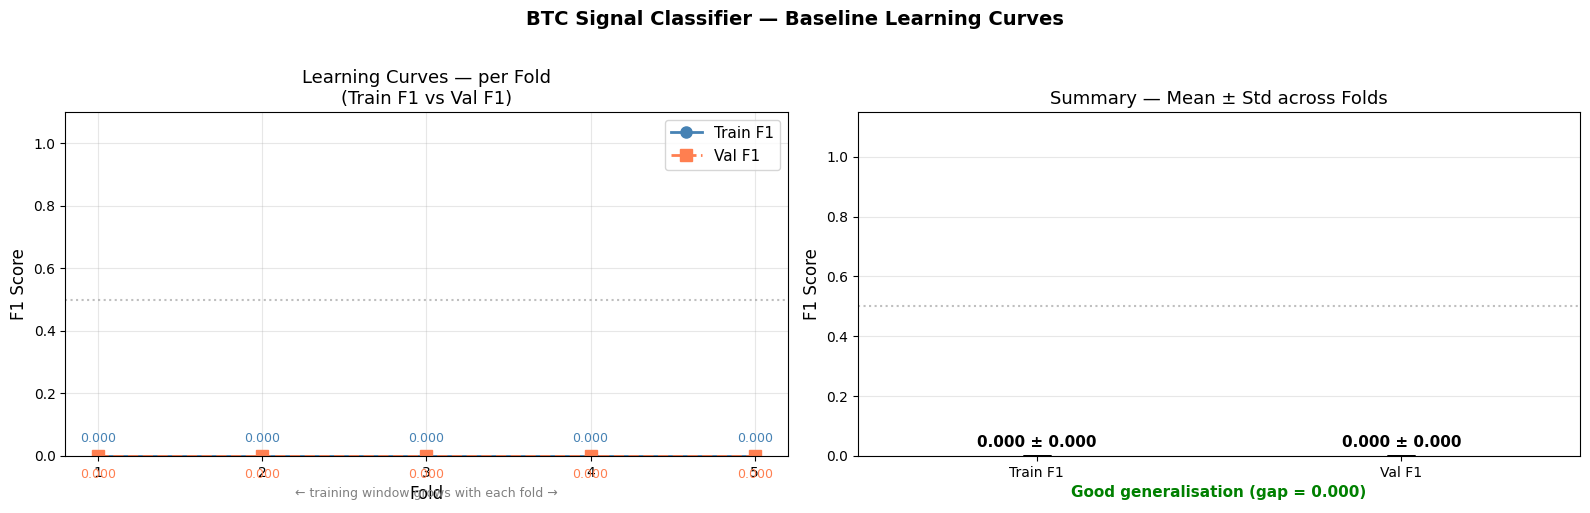

Train-Val gap: 0.000  →  Good generalisation (gap = 0.000)


In [44]:
# ✅ Change 10 + 11: learning curves — per fold and summary

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

folds = list(range(1, len(fold_train_scores) + 1))


# ── Plot 1: Train F1 vs Val F1 per fold ────────────────────────────────────
ax1 = axes[0]

ax1.plot(folds, fold_train_scores,
         'o-', color='steelblue', linewidth=2, markersize=8, label='Train F1')
ax1.plot(folds, fold_val_scores,
         's--', color='coral', linewidth=2, markersize=8, label='Val F1')

for i, (tr, va) in enumerate(zip(fold_train_scores, fold_val_scores)):
    ax1.annotate(f'{tr:.3f}', (i + 1, tr),
                 textcoords='offset points', xytext=(0, 10),
                 ha='center', fontsize=9, color='steelblue')
    ax1.annotate(f'{va:.3f}', (i + 1, va),
                 textcoords='offset points', xytext=(0, -16),
                 ha='center', fontsize=9, color='coral')

ax1.set_xlabel('Fold', fontsize=12)
ax1.set_ylabel('F1 Score', fontsize=12)
ax1.set_title('Learning Curves — per Fold\n(Train F1 vs Val F1)', fontsize=13)
ax1.set_xticks(folds)
ax1.set_ylim(0, 1.1)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label='Random baseline')
ax1.annotate('← training window grows with each fold →',
             xy=(0.5, -0.12), xycoords='axes fraction',
             ha='center', fontsize=9, color='gray')


# ── Plot 2: Summary — mean ± std across folds ──────────────────────────────
ax2 = axes[1]

mean_train = np.mean(fold_train_scores)
std_train  = np.std(fold_train_scores)
mean_val   = np.mean(fold_val_scores)
std_val    = np.std(fold_val_scores)

bars = ax2.bar(
    ['Train F1', 'Val F1'],
    [mean_train, mean_val],
    yerr=[std_train, std_val],
    color=['steelblue', 'coral'],
    alpha=0.8,
    capsize=10,
    edgecolor='white',
    linewidth=1.5,
    error_kw={'elinewidth': 2, 'ecolor': 'black', 'capthick': 2}
)

for bar, mean, std in zip(bars, [mean_train, mean_val], [std_train, std_val]):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        mean + std + 0.02,
        f'{mean:.3f} ± {std:.3f}',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax2.set_ylabel('F1 Score', fontsize=12)
ax2.set_title('Summary — Mean ± Std across Folds', fontsize=13)
ax2.set_ylim(0, 1.15)
ax2.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)
ax2.grid(True, alpha=0.3, axis='y')

# Overfitting verdict
gap = mean_train - mean_val
if gap > 0.15:
    verdict = f'Overfitting detected (gap = {gap:.3f})'
    color   = 'red'
elif gap > 0.05:
    verdict = f'Slight overfitting (gap = {gap:.3f})'
    color   = 'orange'
else:
    verdict = f'Good generalisation (gap = {gap:.3f})'
    color   = 'green'

ax2.text(0.5, -0.12, verdict,
         transform=ax2.transAxes,
         ha='center', fontsize=11, color=color, fontweight='bold')

plt.suptitle('BTC Signal Classifier — Baseline Learning Curves',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('learning_curves_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Train-Val gap: {gap:.3f}  →  {verdict}")

## 8 — Final Evaluation on Holdout Set

### ✅ Change 12 — Final model trained on full `X_train` → evaluated once on `X_holdout`

🔒 **`X_holdout` is opened here for the first and only time.**

The final model is retrained on the full `X_train` (all 5 folds combined) before evaluating on the holdout set. This gives the model the maximum available training data.

In [45]:
# ✅ Change 12: train final model on full X_train, evaluate once on X_holdout
# Previous: no holdout — no genuinely unseen final evaluation
# Now:      pipe.fit(X_train) → pipe.predict(X_holdout) — once, at the end

print("Training final model on full X_train...")
final_start = time.time()

pipe.fit(X_train, y_train)

final_elapsed = time.time() - final_start
print(f"Final model training time: {final_elapsed:.1f}s")

# 🔒 First and only time X_holdout is used
y_holdout_pred = pipe.predict(X_holdout)

print("\n" + "=" * 60)
print("FINAL EVALUATION — HOLDOUT SET")
print("(never seen during Walk-Forward CV)")
print("=" * 60)
print(f"Holdout period: {X_holdout.index[0].date()}  →  {X_holdout.index[-1].date()}")
print(f"Holdout bars:   {len(X_holdout):,}")
print("=" * 60 + "\n")

print(classification_report(
    y_holdout,
    y_holdout_pred,
    target_names=['FLAT (0)', 'BUY (1)']
))

Training final model on full X_train...
Final model training time: 1.3s

FINAL EVALUATION — HOLDOUT SET
(never seen during Walk-Forward CV)
Holdout period: 2024-07-20  →  2026-03-07
Holdout bars:   14,283

              precision    recall  f1-score   support

    FLAT (0)       0.70      0.67      0.68      9963
     BUY (1)       0.31      0.34      0.32      4320

    accuracy                           0.57     14283
   macro avg       0.50      0.50      0.50     14283
weighted avg       0.58      0.57      0.58     14283



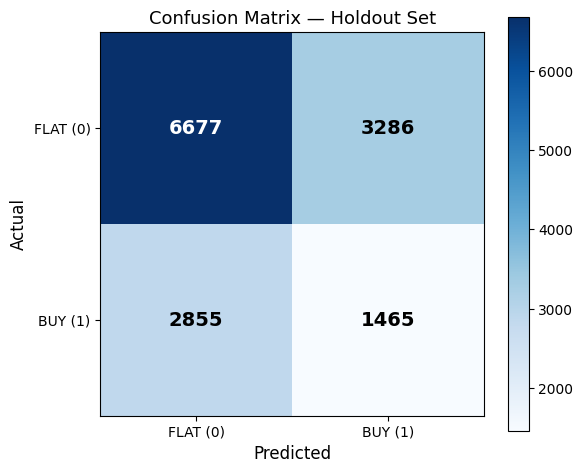

In [46]:
# Confusion Matrix — Holdout Set

cm = confusion_matrix(y_holdout, y_holdout_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im)

tick_marks = [0, 1]
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(['FLAT (0)', 'BUY (1)'])
ax.set_yticklabels(['FLAT (0)', 'BUY (1)'])

for i in range(2):
    for j in range(2):
        ax.text(
            j, i, str(cm[i, j]),
            ha='center', va='center',
            color='white' if cm[i, j] > cm.max() / 2 else 'black',
            fontsize=14, fontweight='bold'
        )

ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix — Holdout Set', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix_holdout.png', dpi=150, bbox_inches='tight')
plt.show()

In [47]:
# CV vs Holdout comparison — sanity check
# Holdout score is almost always lower than CV score
# A large gap between the two indicates overfitting to the training period

holdout_prec = precision_score(y_holdout, y_holdout_pred, zero_division=0)
holdout_rec  = recall_score(y_holdout, y_holdout_pred, zero_division=0)
holdout_f1   = f1_score(y_holdout, y_holdout_pred, zero_division=0)

print("CV vs Holdout — Sanity Check")
print("=" * 50)
print(f"Mean CV Val F1:     {np.mean(fold_val_scores):.3f} ± {np.std(fold_val_scores):.3f}")
print(f"Holdout F1:         {holdout_f1:.3f}")
print()
print(f"Mean CV Precision:  {metrics_df['Val Precision'].mean():.3f}")
print(f"Holdout Precision:  {holdout_prec:.3f}")
print()
cv_holdout_gap = np.mean(fold_val_scores) - holdout_f1
print(f"CV → Holdout gap:   {cv_holdout_gap:.3f}")
if cv_holdout_gap > 0.10:
    print("⚠️  Large gap — model may be overfitting to the 2018-2024 period")
else:
    print("✅  Small gap — model generalises reasonably across time periods")

CV vs Holdout — Sanity Check
Mean CV Val F1:     0.000 ± 0.000
Holdout F1:         0.323

Mean CV Precision:  0.000
Holdout Precision:  0.308

CV → Holdout gap:   -0.323
✅  Small gap — model generalises reasonably across time periods


## 9 - Precision-Recall-Curve  

At 60.0% Precision, the Recall is 50.98%


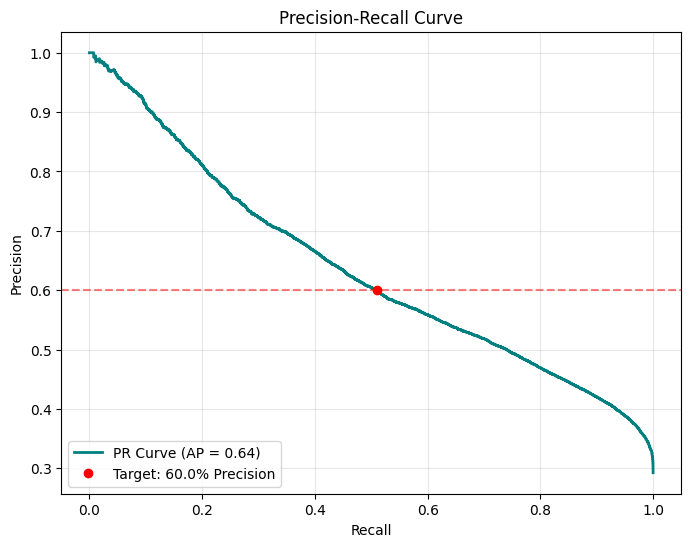

In [48]:
from sklearn.metrics import precision_recall_curve, average_precision_score

y_scores = pipe.predict_proba(X_train)[:,1]

precision, recall, thresholds = precision_recall_curve(y_train, y_scores)
avg_precision = average_precision_score(y_train, y_scores)

# 3. Find the recall when precision is at least 60%
target_precision = 0.60
# We find indices where precision is >= 60% and take the one with the highest recall
indices = np.where(precision >= target_precision)[0]
if indices.size > 0:
    best_index = indices[np.argmax(recall[indices])]
    target_recall = recall[best_index]
    target_threshold = thresholds[min(best_index, len(thresholds)-1)]
    print(f"At {target_precision*100}% Precision, the Recall is {target_recall*100:.2f}%")
else:
    print("Precision target never reached.")

# 4. Plotting
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='teal', lw=2, label=f'PR Curve (AP = {avg_precision:.2f})')

# Add the target threshold point
plt.plot(target_recall, target_precision, 'ro', label=f'Target: {target_precision*100}% Precision')
plt.axhline(y=target_precision, color='r', linestyle='--', alpha=0.5)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.show()

## Classification Report

In [49]:
# 1. Final Fit on the entire Training Set
# (Now that we've tuned it with CV, we use all 80% of data to train)
pipe.fit(X_train, y_train)

# 2. Predict on the 20% Holdout Set
y_probs = pipe.predict_proba(X_holdout)[:, 1]
y_pred = (y_probs >= target_threshold).astype(int)

# 3. Generate the Report
report = classification_report(y_holdout, y_pred, target_names=['FLAT', 'BUY'])
print("Final Evaluation on Holdout Set (2024-2026):")
print("-" * 60)
print(report)


Final Evaluation on Holdout Set (2024-2026):
------------------------------------------------------------
              precision    recall  f1-score   support

        FLAT       0.70      0.82      0.76      9963
         BUY       0.32      0.20      0.25      4320

    accuracy                           0.63     14283
   macro avg       0.51      0.51      0.50     14283
weighted avg       0.59      0.63      0.60     14283



## 10 - SHAP Values

In [50]:
# !pip install shap
import shap
# Run the following command. Needed for some visualizations.
shap.initjs();

In [51]:
pipe.named_steps

{'model': LGBMClassifier(colsample_bytree=0.7, learning_rate=0.05, max_depth=5,
                n_estimators=500, num_leaves=15, objective='binary',
                random_state=42, reg_alpha=0.01, reg_lambda=0.01,
                scale_pos_weight=np.float64(2.4173783218871305), verbose=-1)}

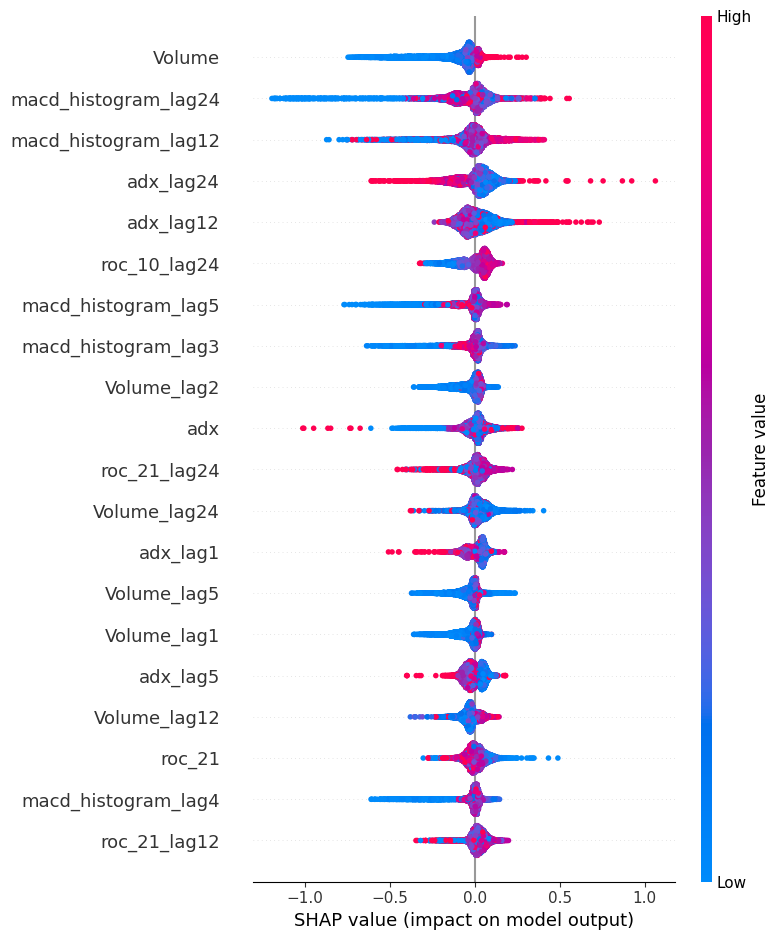

In [52]:
# 1. Extract the model
model = pipe.named_steps['model']

# 2. Use TreeExplainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_holdout)

# 3. Handle the "List vs Matrix" logic
# If SHAP returns a list (usually [neg_class, pos_class]), take the second one.
# If it returns a single matrix, use it directly.
if isinstance(shap_values, list):
    val_to_plot = shap_values[1]
else:
    val_to_plot = shap_values

# 4. Plot
shap.summary_plot(val_to_plot, X_holdout)